# Weather Typing

## Predictor - Load large scale atmospheric variables

### mean sea level pressure, spatial gradient of mean sea level pressure

In [ ]:
from utils.data import load_atmospheric_predictor

# Define the variables and region
variables = ["msl", "msl_gradient"]
region = (200, -10, 360, 80)
estela = True

# Load the ERA5 dynamic predictors
era5_dynamic = load_atmospheric_predictor(
    variables=variables, region=region, estela=estela
)
era5_dynamic

In [ ]:
# If cell above takes too long, interrupt kernel and run:
!wget https://geoocean.sci.unican.es/data/era5_predictor_dynamic_aveiro.nc -P inputs/

# Then run:
import xarray as xr

era5_dynamic = xr.open_dataset("inputs/era5_predictor_dynamic_aveiro.nc")
era5_dynamic

--2025-08-26 07:15:23--  https://geoocean.sci.unican.es/data/era5_predictor_dynamic_aveiro.nc
Resolving geoocean.sci.unican.es (geoocean.sci.unican.es)... 193.144.184.39
Connecting to geoocean.sci.unican.es (geoocean.sci.unican.es)|193.144.184.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 123823132 (118M) [application/octet-stream]
Saving to: ‘inputs/era5_predictor_dynamic_aveiro.nc’

era5_predictor_dyna 100%[===================>] 118.09M  23.3MB/s    in 6.1s    

2025-08-26 07:15:30 (19.3 MB/s) - ‘inputs/era5_predictor_dynamic_aveiro.nc’ saved [123823132/123823132]



<xarray.Dataset> Size: 124MB
Dimensions:       (time: 16802, latitude: 23, longitude: 40)
Coordinates:
  * latitude      (latitude) float32 92B 80.0 76.0 72.0 68.0 ... 0.0 -4.0 -8.0
  * longitude     (longitude) float32 160B 200.0 204.0 208.0 ... 352.0 356.0
  * time          (time) datetime64[ns] 134kB 1979-01-01 ... 2024-12-31
Data variables:
    msl           (time, latitude, longitude) float32 62MB ...
    msl_gradient  (time, latitude, longitude) float32 62MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Predictor - Define weather types

### PCA + KMA

In [5]:
from bluemath_tk.datamining.kma import KMA
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.predictor.xwt import XWT

pca = PCA(n_components=0.9)
kma = KMA(num_clusters=36, seed=42)

xwt = XWT(steps={"pca": pca, "kma": kma})
xwt.fit(
    data=era5_dynamic,
    fit_params={
        "pca": {
            "vars_to_stack": variables,
            "coords_to_stack": ["latitude", "longitude"],
            "pca_dim_for_rows": "time",
            "value_to_replace_nans": {"msl": 101325.0, "msl_gradient": 0.0},
        },
        "kma": {
            "normalize_data": False,
            "min_number_of_points": 25,
            "max_number_of_iterations": 100,
        },
    },
    variable_to_sort_bmus="msl",
)

# xwt._exclude_attributes = []  # To save data used for fitting
xwt.save_model("outputs/dwt_model_aveiro.pkl")

2025-08-26 07:16:06,652 - PCA - WARNING - Using 205 out of 920 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2025-08-26 07:16:06,680 - PCA - WARNING - Data contains NaNs.
2025-08-26 07:16:06,751 - PCA - WARNING - Using 205 out of 920 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2025-08-26 07:16:06,774 - PCA - WARNING - Data contains NaNs.
2025-08-26 07:16:47,363 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


## Predictor - Describe Weather Types

### Plotting + Statistics

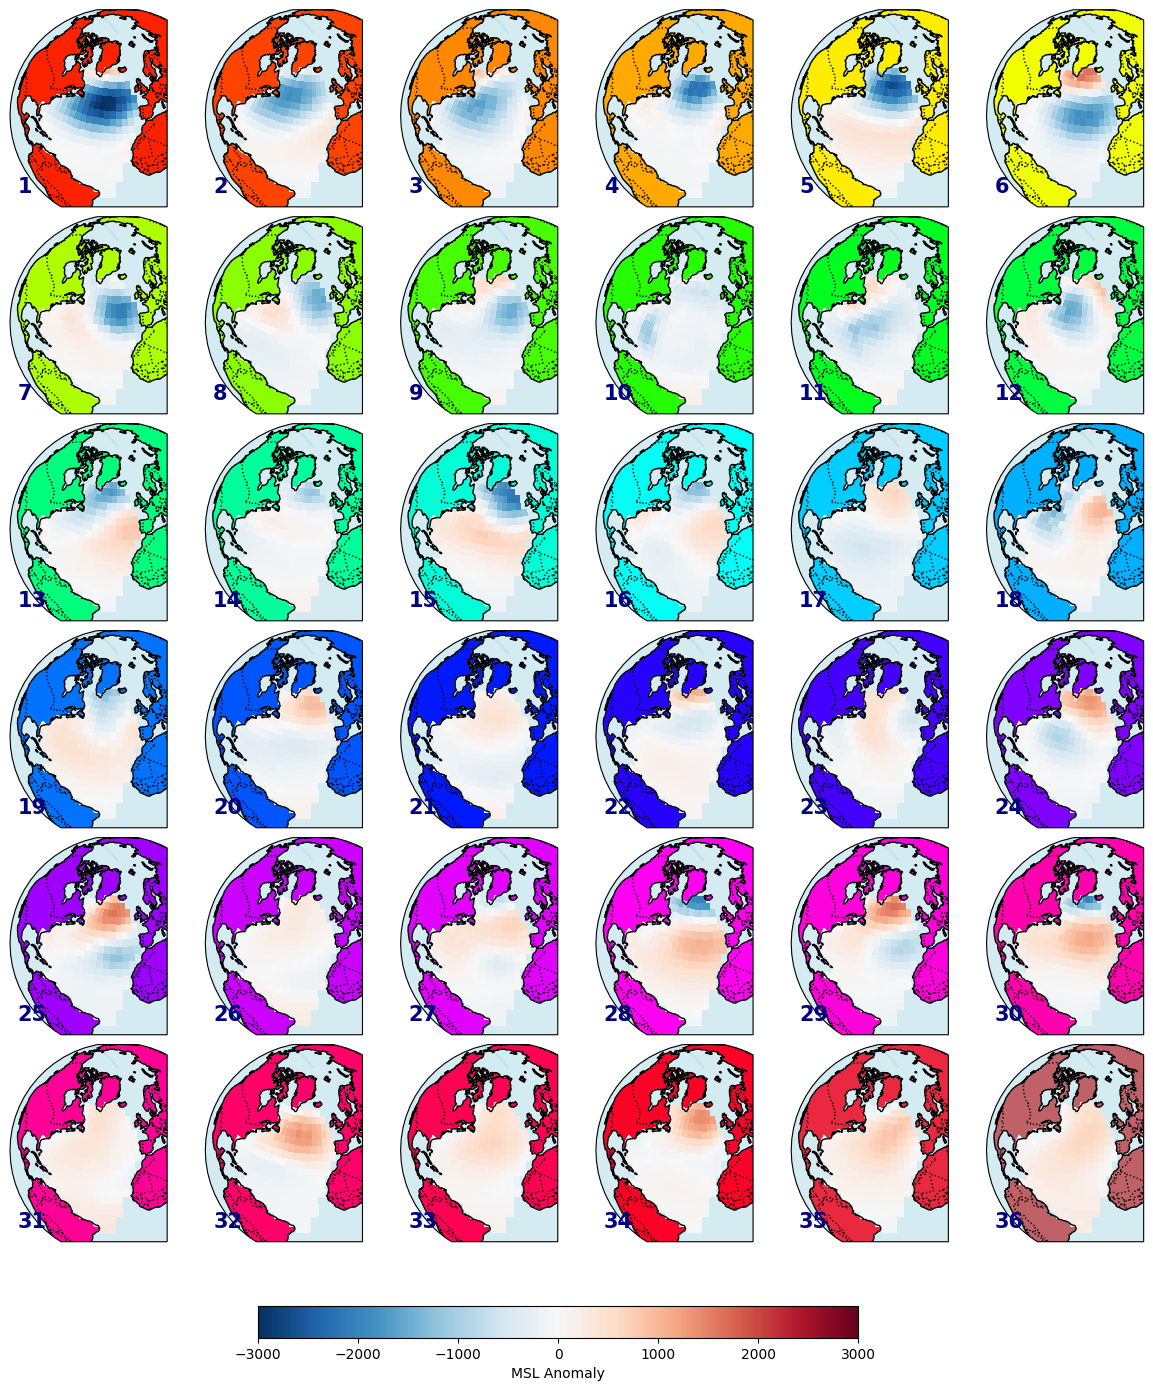

In [6]:
from bluemath_tk.predictor.xwt import config_variables

config_variables["msl"] = {
    "vmin": -3000,
    "vmax": 3000,
    "label": "MSL Anomaly",
}
xwt.plot_xwts(var_to_plot="msl", anomaly=True, map_center=(-25, 40))

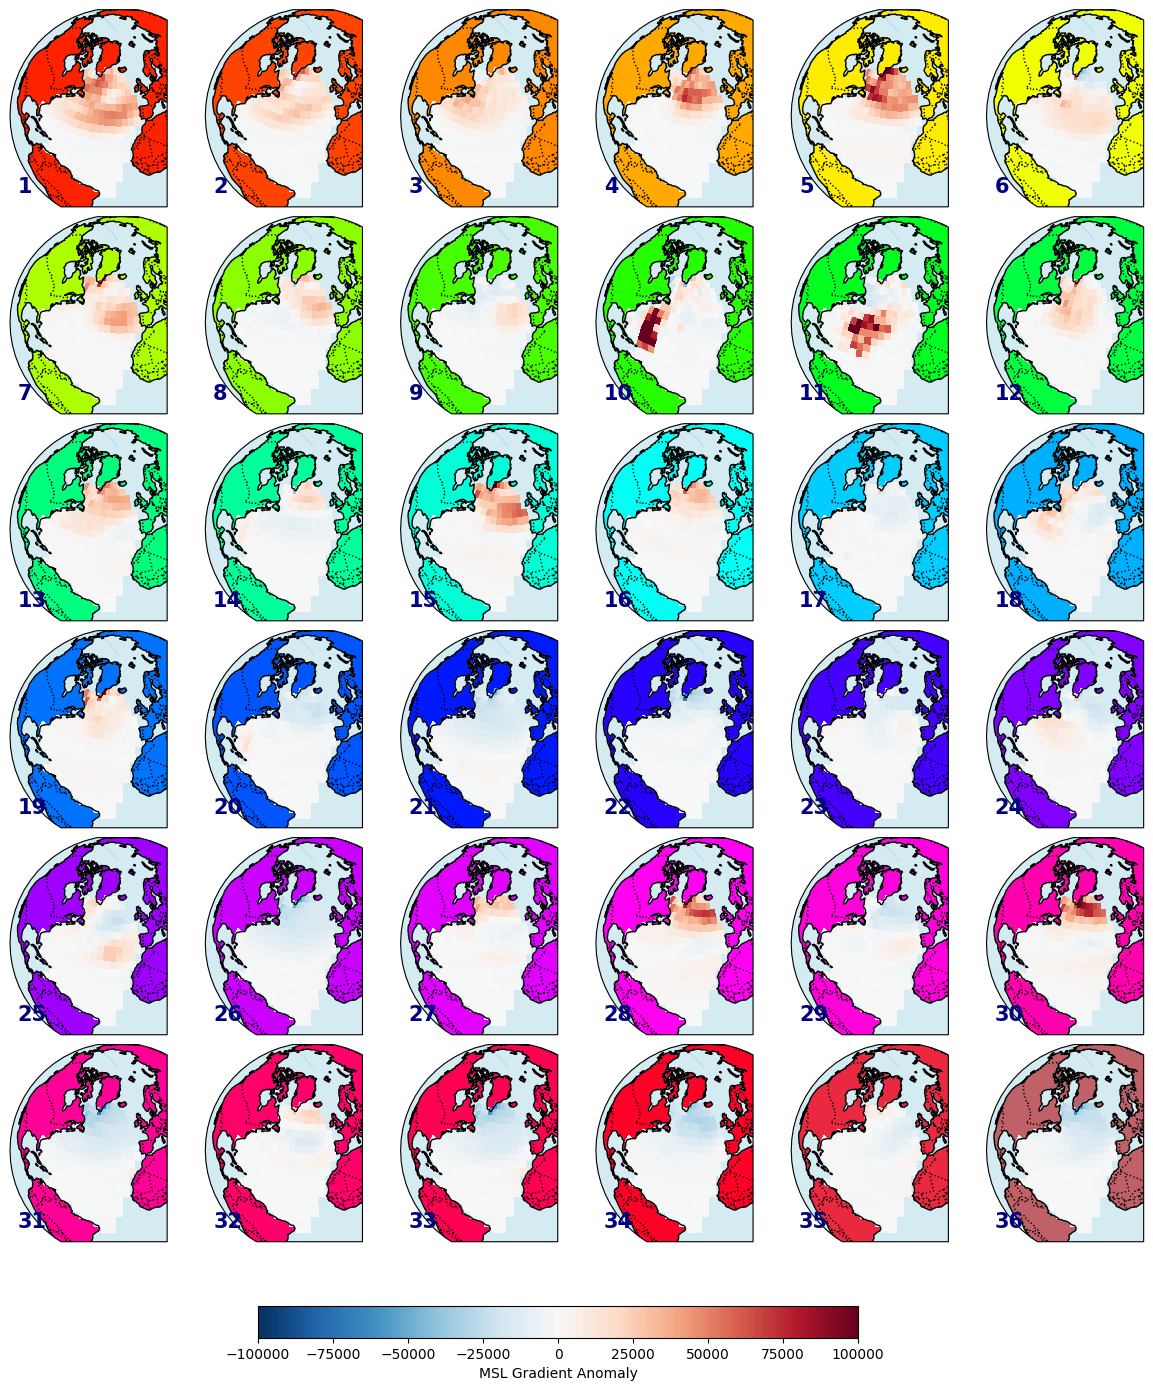

In [8]:
from bluemath_tk.predictor.xwt import config_variables

config_variables["msl_gradient"] = {
    "vmin": -0.1 * 1e6,
    "vmax": 0.1 * 1e6,
    "label": "MSL Gradient Anomaly",
}
xwt.plot_xwts(var_to_plot="msl_gradient", anomaly=True, map_center=(-25, 40))

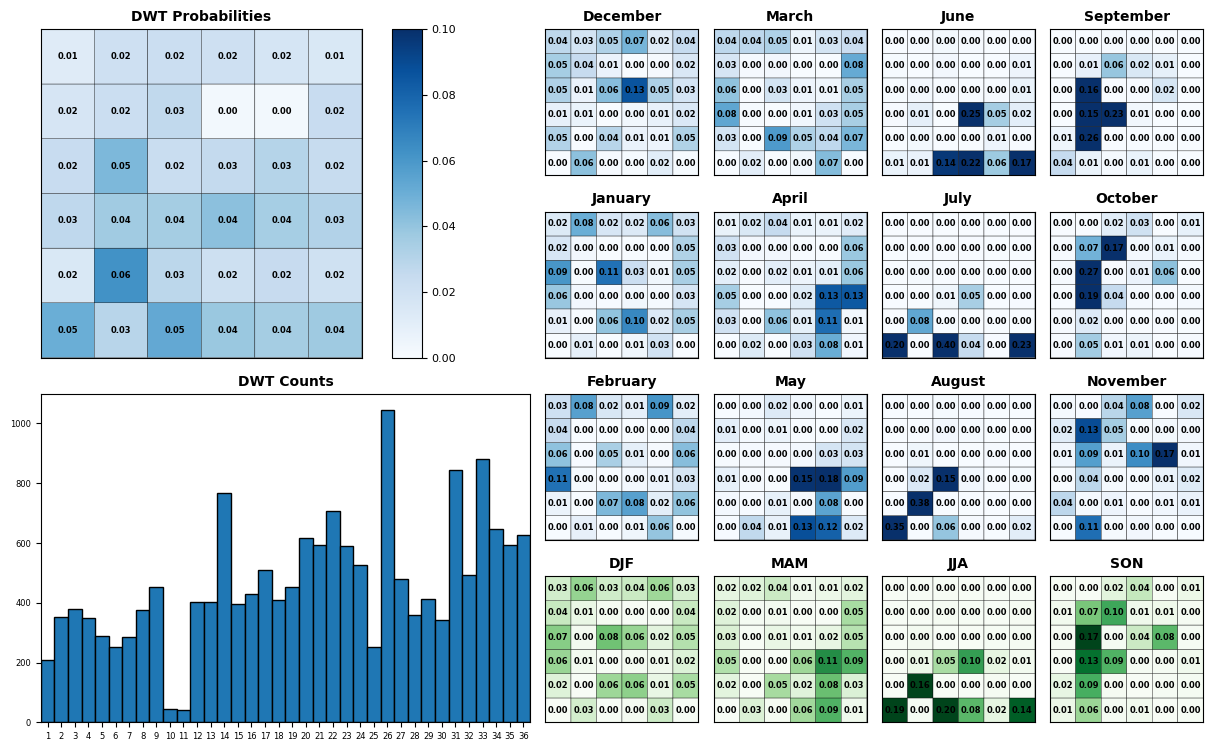

In [9]:
xwt.plot_dwts_probs(plot_text=True)

<Axes: >

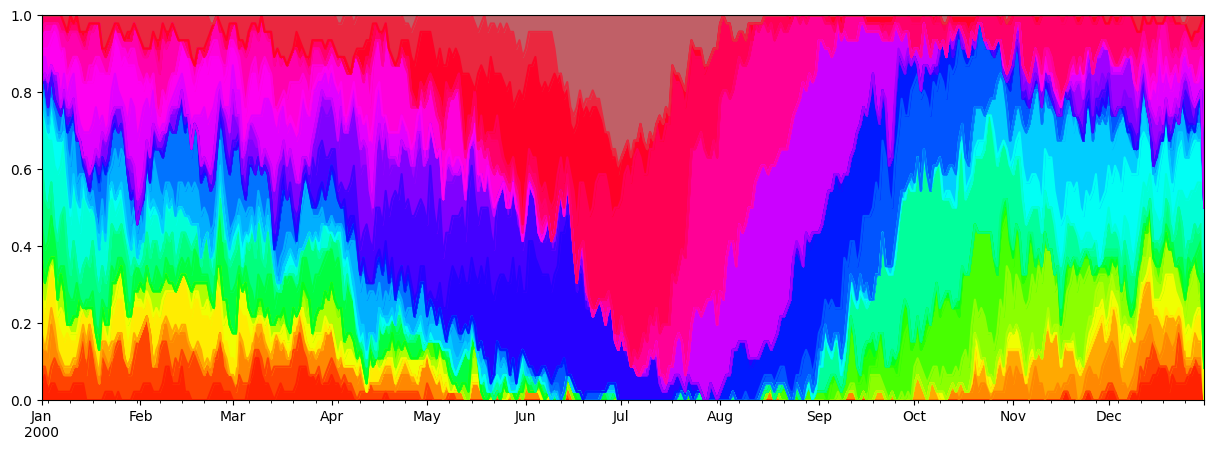

In [10]:
xwt.plot_perpetual_year()

## Predictand - Load regional/local wave data

### significant wave height, peak period, mean wave direction

In [11]:
import xarray as xr

waves = xr.open_dataset("inputs/waves_EF_daily.nc").sel(
    time=xwt.kma_bmus.index.values, method="nearest"
)
waves["kma_bmus"] = (("time"), xwt.kma_bmus.kma_bmus.values)
waves

<xarray.Dataset> Size: 739kB
Dimensions:    (time: 16802)
Coordinates:
    longitude  float32 4B ...
    latitude   float32 4B ...
  * time       (time) datetime64[ns] 134kB 1979-01-01 1979-01-02 ... 2023-12-31
Data variables:
    swh        (time) float64 134kB ...
    pp1d       (time) float64 134kB ...
    mwd        (time) float64 134kB ...
    EF         (time) float64 134kB ...
    kma_bmus   (time) int32 67kB 20 20 20 20 20 20 32 ... 30 30 35 30 35 27 27
Attributes:
    Conventions:  CF-1.6
    history:      2024-05-24 23:51:43 GMT by grib_to_netcdf-2.28.1: /opt/ecmw...

## Predictand to Predictor - Model

### Empirical distribution of wave parameters conditioned to each weather type

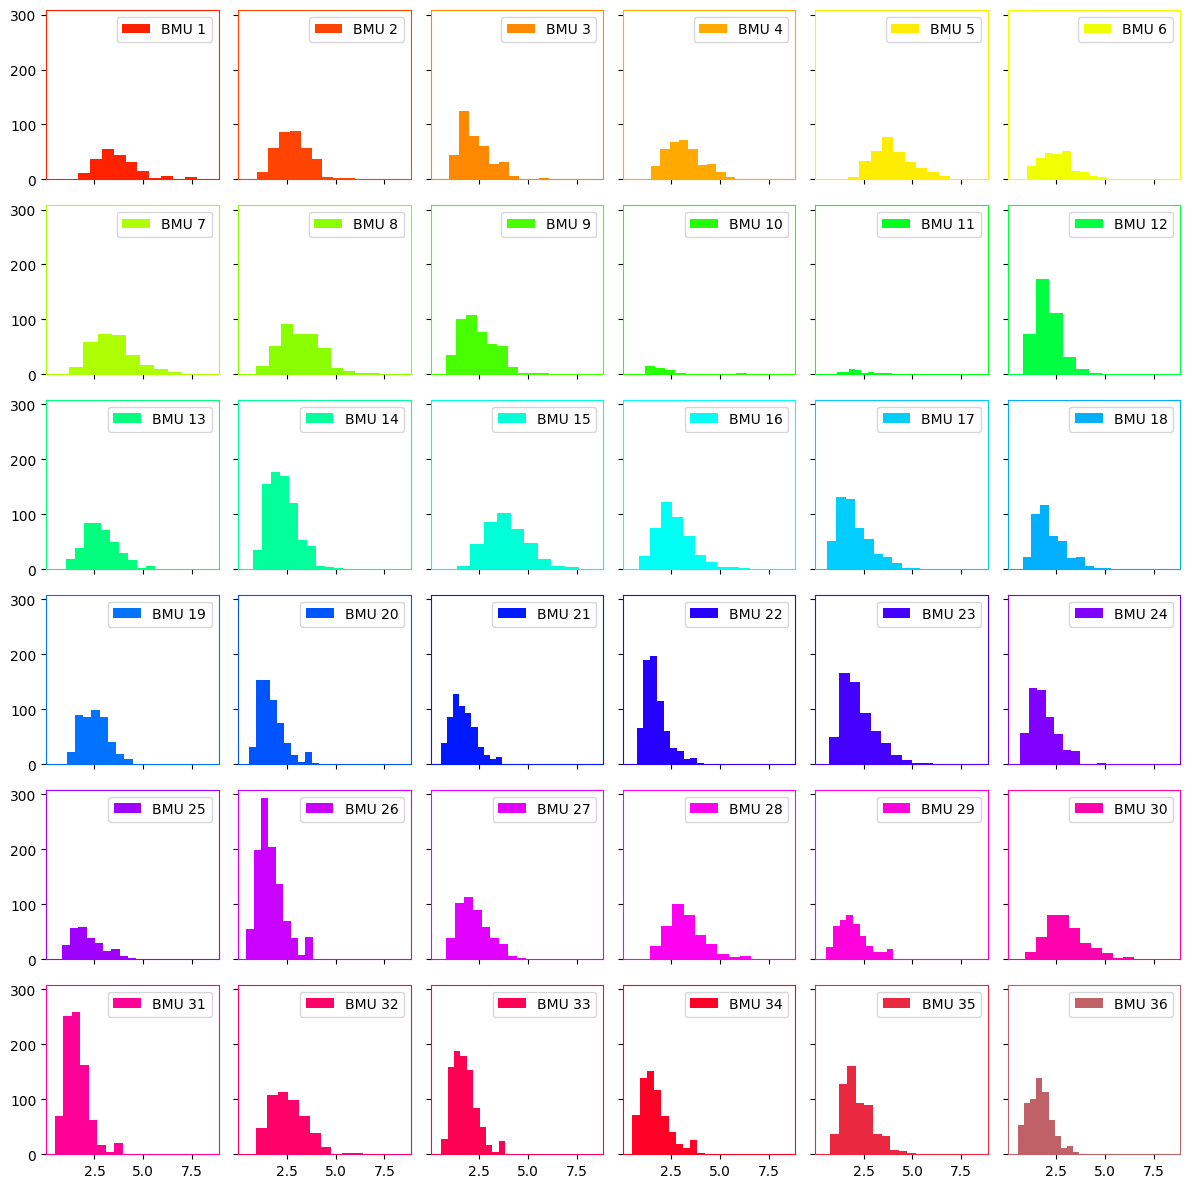

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from bluemath_tk.core.plotting.colors import get_cluster_colors

wave_variable = "swh"

cluster_colors = get_cluster_colors(xwt.num_clusters)
fig, axes = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)
for ax, kma_bmus_index, color in zip(axes.flatten(), range(1, 37), cluster_colors):
    bmus_indexes = np.where(waves["kma_bmus"].values == kma_bmus_index)[0]
    try:
        waves[wave_variable].isel(time=bmus_indexes).squeeze().plot.hist(
            ax=ax, color=color, label=f"BMU {kma_bmus_index}"
        )
        ax.legend()
        ax.set_title("")
        ax.set_xlabel("")
        for border in ["top", "bottom", "left", "right"]:
            ax.spines[border].set_color(color)
    except:
        pass

plt.tight_layout()